*In this blog post, I am sharing a slightly-modified version of a presentation I gave to HEC Montreal's "Research Day on Open Science and Replications in Marketing". It is called "A Critical Perspective on Effect Sizes".*

*I start with a quick refresher on what effect sizes are, discuss the conditions under which effect sizes contain useful information, and conclude by offering some heuristics to evaluate effect sizes.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
from IPython.display import HTML, Markdown, display

_, _, green, red = sns.color_palette(n_colors=4)
pal = sns.color_palette()


def plot_interval(ax, x1, x2, y, *args, **kwargs):
    ax.plot([x1 * 1.01, x2 * 0.99], [y, y], *args, ls=":", **kwargs)
    ax.annotate("<", [x1, y], *args, ha="left", va="center", **kwargs)
    ax.annotate(">", [x2, y], ha="right", va="center", **kwargs)

Over the past decade, a growing number of marketing journals have started recommending (or even requiring) that authors report the effect sizes associated with their statistical test. 

The previous editorial team of the Journal of Consumer Research justified this decision as follow: "We believe that transparent and full reporting will enable others to understand the research and weight of evidence for the research findings" (Inman et al., 2016).

While I enthusiastically agree with the decision and with the rationale, it is not straightforward that effect sizes always allow researchers to "understand the [...] weight of evidence for the research findings". Specifically, I believe that effects sizes are only helpful if they are:
* Understood
* Informative
* Contextualized

Let's go over each of these criteria.

## Effect Sizes Need to be Understood

Papers can report a plethora of different effect size metrics, and I don't think it is always clear what they mean.

Check for yourself:
* What is the difference between Hedge's *g*, Cohen's *d*, and the Glass $\Delta$?
* What about the difference between $\eta^2$ and $\eta^2_{p}$? 
* Between $\epsilon^2$ and $\eta^2$?

If you were able to recall that:
* ... Hedge's *g* includes a small-sample correction that Cohen's *d* doesn't have; that the Glass $\Delta$ (unlike *g* and *d*) scales the mean difference by the standard deviation of the control group (rather than the pooled standard deviation)
* ... the subscript *p* indicates a *partial* effect size (corrected for the variance explained by other predictors) 
* ... and that $\epsilon^2$ (unlike $\eta^2$) includes a correction for the number of predictors;

Congratulations! You know more than I did when I started researching this topic, and can probably skip to the next section of the article. 

Fortunately, I don't think that these details matter too much. Instead, what everybody should know about effect sizes is much more simple: **They all express, in different ways, the amount of variance in a phenomenon that is explained by a predictor.**

Let's see why and how.

### Some effect sizes directly give us the amount of variance explained

Imagine that respondents, in an experiment, have a certain WTP for a good. The average WTP is 10 dollars, with a variance of $\sigma^2=1$. 

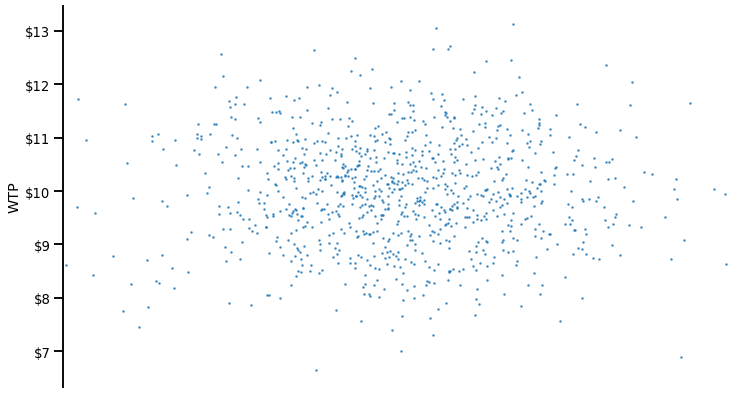

In [2]:
np.random.seed(287933)
mvn = stats.multivariate_normal([10, 4, 4], [[1, 0, 0.8], [0, 1, 0], [0.8, 0, 1]])
wtp, agreeableness, fc = mvn.rvs(1000).T
x = agreeableness
agreeableness = np.round(agreeableness)
fc = np.round(fc)
df = pd.DataFrame(dict(wtp=wtp, agreeableness=agreeableness, fc=fc))
sns.set_context("talk", font_scale=0.8)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.scatter(x, wtp, s=1, alpha=0.8)
ax.set_xlim(1, 7)
ax.set_xlabel("Agreeableness")
ax.set_ylabel("WTP")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:.0f}")
sns.despine(bottom=True)
ax.set_xlabel("")
ax.set_xticks([])
plt.savefig("Figa.png")
plt.close()
display(fig, metadata=dict(filename="Fig1"));

Now, consider a predictor that would be unrelated to this WTP: Agreeableness. Here's the ANOVA of Agreeableness on WTP:

In [3]:
aov = pg.anova(data=df, dv="wtp", between="agreeableness").iloc[0]
display(
    HTML(
        f"F({aov['ddof1']}, {aov['ddof2']})={aov['F']:.2f}, p = {aov['p-unc']:.3f}, $\eta^2$ = {aov['np2']:.3f}"
    )
)

Our statistical software show an $\eta^2$ of 0.004. 

The interpretation of $\eta^2$ is very simple: It directly tells us the amount of variance explained by the predictor, which means here that Agreeableness explains .4% of the variance in WTP. 

We can easily visualize this (lack of) impact on a graph. For clarity, I have overlaid the overall WTP (in blue).

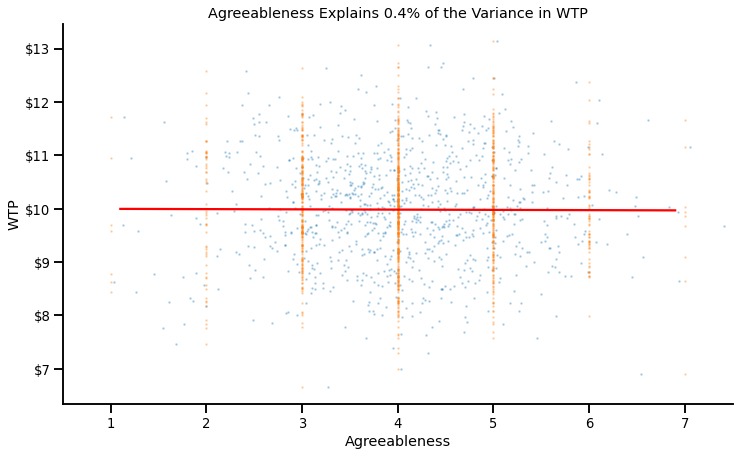

In [4]:
sns.set_context("talk", font_scale=0.8)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.scatter(x, wtp, s=1, alpha=0.3)
ax.scatter(agreeableness, wtp, s=1, alpha=0.3)
ax.set_xlim(0.5, 7.5)
ax.set_xlabel("Agreeableness")
ax.set_ylabel("WTP")
param = sm.OLS(wtp, sm.add_constant(agreeableness)).fit().params[1]
ax.plot([1.1, 6.9], [10 + 1.1 * param, 10 + 6.9 * param], color="red")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:.0f}")
sns.despine()
ax.set_title("Agreeableness Explains 0.4% of the Variance in WTP")
plt.savefig("Figb.png")
plt.close()
display(fig, metadata=dict(filename="Fig2"));

We can see that:
* The variance explained by Agreeableness is quasi-null: People at low (vs. high) levels of agreeableness have the same WTP
* As a consequence, the residual variance in WTP at any given level of Agreableness is equal to the overall amount of variance

Now, what happens when we instead consider a very strong predictor of WTP: Financial constraints? Again, here's the ANOVA:

In [5]:
aov = pg.anova(data=df, dv="wtp", between="fc").iloc[0]
display(
    HTML(
        f"F({aov['ddof1']}, {aov['ddof2']})={aov['F']:.2f}, p < .001, $\eta^2$ = {aov['np2']:.3f}"
    )
)

It has an $\eta^2$ of 0.614, which again means Financial Constraints explain 61.4% of the variance in WTP. 

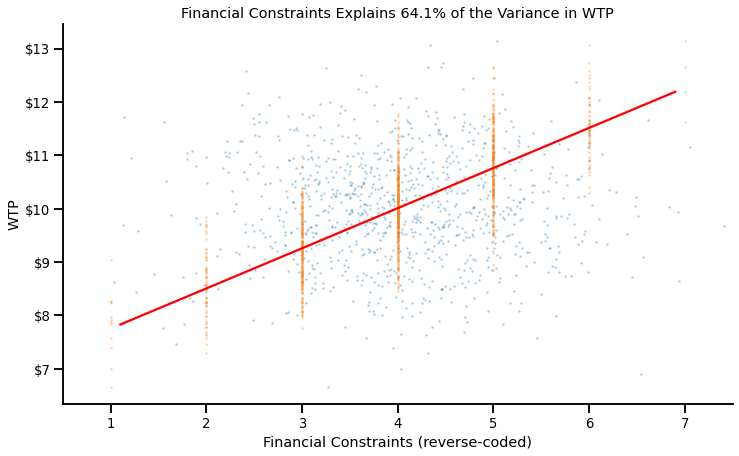

In [6]:
sns.set_context("talk", font_scale=0.8)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.scatter(x, wtp, s=1, alpha=0.3)
ax.scatter(fc, wtp, s=1, alpha=0.3)
ax.set_xlim(0.5, 7.5)
ax.set_xlabel("Financial Constraints (reverse-coded)")
ax.set_ylabel("WTP")
a, b = sm.OLS(wtp, sm.add_constant(fc)).fit().params
ax.plot([1.1, 6.9], [a + 1.1 * b, a + 6.9 * b], color="red")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:.0f}")
sns.despine()
ax.set_title("Financial Constraints Explains 64.1% of the Variance in WTP")
plt.savefig("Figc.png")
plt.close()
display(fig, metadata=dict(filename="Fig3"));

If we plot their relationship, we can indeed see this strong association:
* The variance explained by Financial Constraints is very high: People at low (vs. high) levels of Financial Constraints have a much lower (vs. higher) WTP.
* As a consequence, the residual variance in WTP at any given level of Financial Constraints is much smaller than the overall amount of variance.

For now, let's remember this: $\eta^2$, $\eta^2_p$, $\epsilon_p$, $\epsilon^2_p$, $\omega^2$ and $\omega^2_p$ all tell us (roughly) the percentage of the variance in a phenomenon that is explained by a predictor.

### Others also tell us the amount of variance explained, but indirectly!

This is the case of a very common effect size, the Cohen's *d*.

The Cohen's *d* expresses the mean difference between two conditions as a function of the pooled variance

$$d = \frac{M_1-M_2}{\sigma_{pooled}}$$

See below for a visual illustration of a Cohen's d = 1.5:

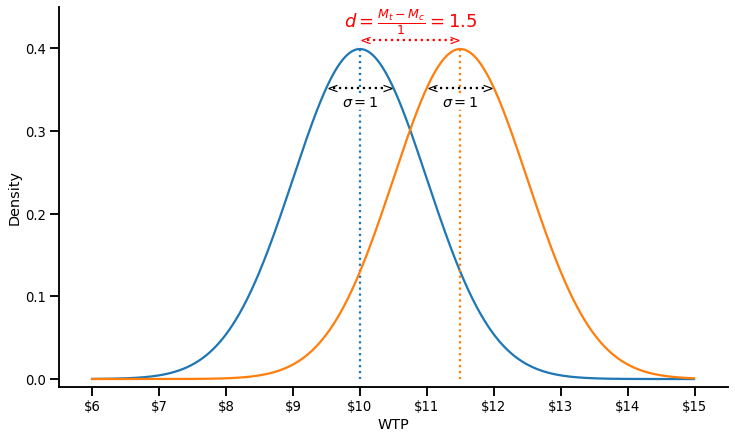

In [7]:
x = np.arange(10 - 4, 10 + 5, 0.01)
a = stats.norm(10, 1).pdf(x)
b = stats.norm(11.5, 1).pdf(x)
h = stats.norm.pdf(-0.5)
mh = stats.norm.pdf(0)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.set_xticks(np.arange(6, 16, 1))
ax.set_ylim(-0.01, 0.45)
ax.set_xlim(5.5, 15.5)
ax.set_xlabel("WTP")
ax.set_ylabel("Density")
ax.plot(x, a, color=pal[0])
ax.plot([10, 10], [mh, 0], color=pal[0], ls=":")
ax.xaxis.set_major_formatter(lambda x, pos: f"${x:.0f}")
sns.despine()

ax.plot(x, b, color=pal[1])
ax.plot([11.5, 11.5], [mh, 0], color=pal[1], ls=":")

plot_interval(ax, 9.5, 10.5, h, color="black")
plot_interval(ax, 11, 12, h, color="black")
plot_interval(ax, 10, 11.5, 0.41, color="red")
ax.annotate(
    "$\sigma = 1$",
    [11.5, h * 0.95],
    ha="center",
    va="center",
    bbox=dict(fc="white", ec="white", pad=0.1),
)
ax.annotate(
    "$\sigma = 1$",
    [10, h * 0.95],
    ha="center",
    va="center",
    bbox=dict(fc="white", ec="white", pad=0.1),
)
ax.annotate(
    "$d = \\frac{M_t - M_c}{1} = 1.5$",
    [10.75, 0.45],
    ha="center",
    va="top",
    size=18,
    color="red",
)
plt.close()
display(fig, metadata=dict(filename="Fig4"));

The difference in WTP between the two conditions is 1.5 dollars, and the pooled standard deviation is 1, which gives us a Cohen's d of 1.5.

This might not be immediately obvious, but we can also express this relationship as a fraction of variance explained, as shown in the graph below:

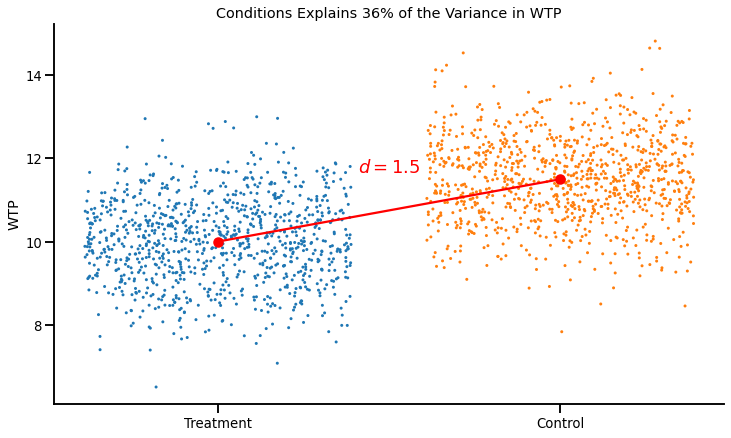

In [8]:
mvn = stats.multivariate_normal([10, 11.5], [[1, 0], [0, 1]])
a, b = mvn.rvs(1000).T
sns.set_context("talk", font_scale=0.8)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
df = pd.DataFrame(
    {"Condition": np.repeat(["Treatment", "Control"], 1000), "WTP": np.hstack([a, b])}
)
sns.stripplot(x="Condition", y="WTP", data=df, s=3, jitter=0.39)
ax.set_xlabel("")
ax.plot([0, 1], [10, 11.5], color="red", zorder=10)
ax.scatter([0, 1], [10, 11.5], color="red", zorder=10)
ax.set_title("Conditions Explains 36% of the Variance in WTP")
ax.annotate("$d = 1.5$", [0.5, 12], ha="center", va="top", size=18, color="red")
sns.despine()
plt.close()
display(fig, metadata=dict(filename="Fig5"));

This graph clearly shows how a Cohen's d relates to the fraction of variance explained: 
* A large Cohen's d means that the difference between conditions is large...
* ... and that the residual variance within conditions is small

In fact, there's a simple formula one can use to express a Cohen's d as a proportion of variance explained:

$$\eta^2 = \left(\frac{d}{\sqrt{d^2+4}}\right)^2$$

... Or you can use convenient online calculators, such as [this one](https://www.psychometrica.de/effect_size.html), or your favorite statistical package.

## Effect Sizes Need to be Informative

The second important nuance about effect sizes is that **not all effect sizes reported in papers are informative**.

Consider the following set of statistical results:

In [9]:
obssizes = [20, 40, 50, 100, 150, 300, 500, 220]
obsetas = []
for ssize, pcrit in zip(
    obssizes, [0.034, 0.044, 0.047, 0.038, 0.038, 0.04, 0.05, 0.042]
):
    f = stats.f(1, ssize - 2).ppf(1 - pcrit)
    eta = pg.convert_effsize(
        pg.compute_effsize_from_t(np.sqrt(f), N=ssize),
        input_type="cohen",
        output_type="eta-square",
    )
    obsetas.append(eta)
    display(
        Markdown(f"F(1, {ssize-2}) = {f:.3f}, *p* = {pcrit:.3f}, $\eta^2$= {eta:.3f}")
    )

F(1, 18) = 5.265, *p* = 0.034, $\eta^2$= 0.208

F(1, 38) = 4.340, *p* = 0.044, $\eta^2$= 0.098

F(1, 48) = 4.157, *p* = 0.047, $\eta^2$= 0.077

F(1, 98) = 4.424, *p* = 0.038, $\eta^2$= 0.042

F(1, 148) = 4.383, *p* = 0.038, $\eta^2$= 0.028

F(1, 298) = 4.255, *p* = 0.040, $\eta^2$= 0.014

F(1, 498) = 3.860, *p* = 0.050, $\eta^2$= 0.008

F(1, 218) = 4.184, *p* = 0.042, $\eta^2$= 0.019

At first glance, there is interesting variability in effect sizes: Some experiments yielded large effect sizes, other small effect sizes.

However, we cannot conclude anything from this variability. Why?

Let's plot the effect sizes against sample sizes:

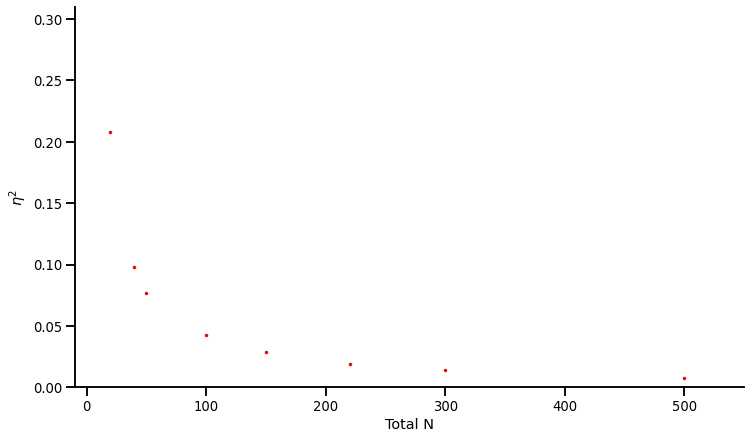

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.scatter(obssizes, obsetas, s=4, color="red")
ax.set_xlim(-10, 550)
ax.set_ylim(0.0, 0.31)
sns.despine()
ax.set_xlabel("Total N")
ax.set_ylabel("$\eta^2$")
plt.close()
display(fig, metadata=dict(filename="Fig6"));

We observe a curious pattern: The experiments with smaller sample sizes produced larger effects, and the experiments with larger sample sizes produced smaller effects... But why?

### In the presence of p-hacking, effect sizes are completely uninformative

If you go back to the statistical results, you'll notice that all the p-values are between .05 and .01... These experiments were (likely) p-hacked! And when an experiment is p-hacked, its effect size becomes meaningless: It simply tells you how big the effect needed to be for the p-value to fall below .05. 

Again, it will become clear on the graph below:

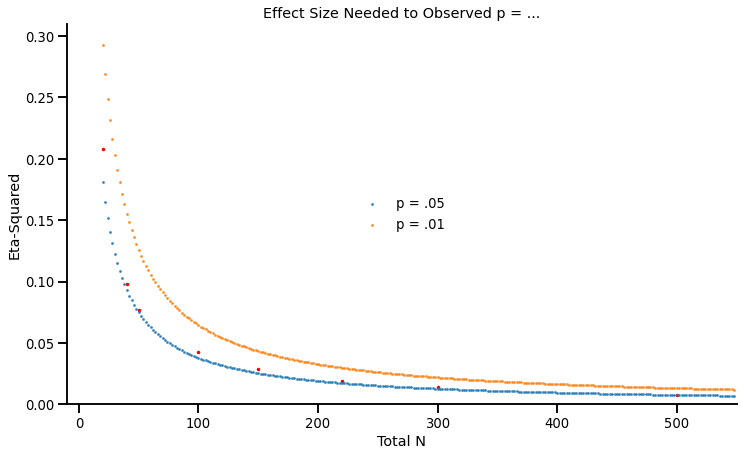

In [11]:
ess05 = []
ess01 = []
ssizes = np.arange(20, 550, 2)
for ssize in ssizes:
    f05 = stats.f(1, ssize - 2).ppf(0.95)
    ess05.append(
        pg.convert_effsize(
            pg.compute_effsize_from_t(np.sqrt(f05), N=ssize),
            input_type="cohen",
            output_type="eta-square",
        )
    )
    f01 = stats.f(1, ssize - 2).ppf(0.99)
    ess01.append(
        pg.convert_effsize(
            pg.compute_effsize_from_t(np.sqrt(f01), N=ssize),
            input_type="cohen",
            output_type="eta-square",
        )
    )
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.scatter(obssizes, obsetas, s=4, color="red")
ax.set_xlim(-10, 550)
ax.set_ylim(0.0, 0.31)
sns.despine()
ax.set_xlabel("Total N")
ax.set_ylabel("Eta-Squared")
plt.savefig("Fig4a.png", dpi=400)
ax.scatter(ssizes, ess05, s=2, label="p = .05", alpha=0.75)
ax.scatter(ssizes, ess01, s=2, label="p = .01", alpha=0.75)
ax.set_title("Effect Size Needed to Observed p = ...")
ax.legend(frameon=False, loc="center")
ax.set_xlim(-10, 550)
ax.set_ylim(0.0, 0.31)
plt.close()
display(fig, metadata=dict(filename="Fig7"));

This graph shows, for a given sample size, the required effect sizes to observe p = .05 (in blue) or p = .01 (in orange). As you can see, the effect sizes of these experiments closely track the blue line. 

It is an important insight. If researchers "p-hack" their results until they cross the significance threshold, the effect sizes that they report do not contain any information: They simply repeat the sample size.


### When studies are underpowered, effect sizes are also less informative


In a more general sense, the less power researchers have in their experiments, the less informative the (published) effect sizes are. Again, a simulation and a graph will be helpful to understand why.

Suppose four different groups of researcher are studying an effect that has a true effect size of $\eta = .01$:
* Group 1 runs a lot of participants per study, such that they have 90% chance of obtaining a significant effect in any experiment.
* Group 2 runs fewer participants, such that they have 50% power to detect the effect in each experiment.
* Group 3 runs even fewer participants, such that they have 30% power.
* Group 2 runs very small groups of participants, such that they only have 10% power.

Of course (☹), the researchers only report the studies that 'worked' and found significant results. What is the effect size that each group will find **in the studies that they report**?

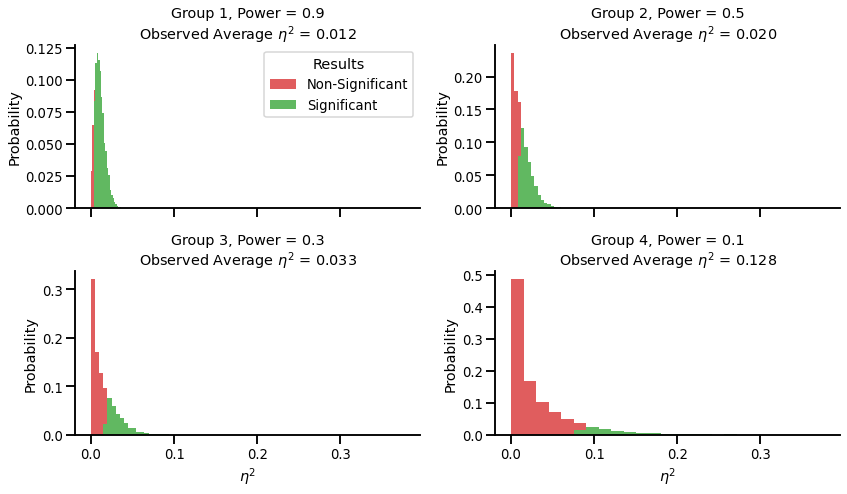

In [12]:
NSIMS = 10000
dvals = np.empty(NSIMS)
pvals = np.empty(NSIMS)
mvn = stats.multivariate_normal(mean=[0, 0.2], cov=[[1, 0], [0, 1]])
datas = {}
for p in [0.1, 0.3, 0.5, 0.9]:
    ns = int(pg.power_ttest(d=0.2, power=p))
    for i in range(NSIMS):
        a, b = mvn.rvs(ns).T
        t = pg.ttest(a, b)
        dvals[i] = t.loc["T-test", "cohen-d"]
        pvals[i] = t.loc["T-test", "p-val"]
    sig = pd.Series(pvals <= 0.05).map({True: "Significant", False: "Non-Significant"})
    datas[p] = pd.DataFrame({"p": pvals, "d": dvals, "Results": sig}).sort_values(
        "Results"
    )
for k, v in datas.items():
    v["etasquared"] = v["d"].apply(
        lambda x: pg.convert_effsize(x, input_type="cohen", output_type="eta-square")
    )
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=False)
axes = axes.flat
for i, k in enumerate([0.9, 0.5, 0.3, 0.1]):
    v = datas[k]
    ax = axes[i]
    leg = i == 0
    sns.histplot(
        v,
        x="etasquared",
        hue="Results",
        bins=25,
        stat="probability",
        multiple="stack",
        common_norm=True,
        legend=leg,
        palette=[red, green],
        ax=ax,
        linewidth=0,
    )
    obs_d = v.query("Results == 'Significant'").etasquared.mean()
    ax.set_title(f"Group {i+1}, Power = {k}\nObserved Average $\\eta^2$ = {obs_d:.3f}")
sns.despine()
plt.tight_layout()
axes[2].set_xlabel("$\\eta^2$")
axes[3].set_xlabel("$\\eta^2$")
plt.close()
display(fig, metadata=dict(filename="Fig8"));

The average observed effect size of the first group, who has 90% power, is very close to the "true" effect size ($\eta^2$ = .012 vs $\eta^2$ = .01). On the other hand, the fourth group, who has 10% power, overestimates the effect size by a factor of more than 12 ($\eta^2$ = .128 vs $\eta^2$ = .01)!

In a nutshell, effect sizes are only informative if the studies are properly powered. As a heuristic:
* The closer the p-value of the study is to .05, the less likely it is that the effect size is informative.
* All effect sizes can assumed to be inflated (since researchers never have 100% power).

## Effect Sizes Need to be Contextualized

Consider the following statistical result:

***Consistent with H1, we find that our manipulation had an impact on people's WTP: F(1, 58) = 81.36, p < .001, $\eta^2$ = .558.***

After our discussion, we know how to interpret the effect size (it means that the IV explains 55.8% of the variance in the DV), and we know that it is likely informative (the F-value is really large, which makes p-hacking implausible, and suggests decent power to detect an effect).

However, we are still missing one crucial element: Reference points against which to interpret this value. I'll offer three ways researchers can use to contextualize effect sizes.


### Using external benchmarks

The most straighforward way to contextualize effect sizes is to compare them to a few real-life phenonenon. This [twitter thread from Brian Nosek](https://twitter.com/BrianNosek/status/1416427265118908419) has a lot of great examples (to interpret the effect sizes r as a percentage of variance explained, simply square it: r = .6 means $\eta^2$ = .36):
* Gender explains 45% of the variance in height in humans
* In the US, distance to the equator explains 36% of the variance in average daily temperature.
* Height explains 19% of the variance in weight in humans

Another approach is to compare them to the results of other psychological studies. One of my favorite paper on the topic is Richard, Bond and Stokes-Zoota's "One Hundred Years of Social Psychology Quantitatively Described" (2003), in which they report the effect sizes of various psychological phenomenon.

Try your intuition: Can you guess the effect sizes of these phenomenon (click on the arrows to reveal the effect sizes)?

<details>
<summary>People are more aggressive toward those who have provoked them</summary>
$\eta^2$ = .261
</details>

<details>
<summary>People are more likely to recycle when they know about recycling, like it, and have an incentive to recycle</summary>
$\eta^2$ = .229
</details>

<details>
<summary>People with low self-esteem often feel bad</summary>
$\eta^2$ = .209
</details>
<br/>
These three examples are some of the largest effect sizes reported in the paper: They find that 95% of the effects are smaller than $\eta^2$ = .25.

However, effect sizes from papers are not always great benchmarks. Not only because they are likely overestimated (as we have discussed earlier), but also because they themselves lack context!

Suppose a meta-analysis says that being pricked by a needle has an effect size of $\eta^2$ = .30 on self-reported pain. But how big was the needle? How often were people pricked? Was the population relatively homogenous in pain level at baseline (e.g., a sample of undergraduates), or was it heterogeneous (e.g., the general population)? All these factors are going to lead to dramatic differences in effect sizes.

What are the alternatives then?

### Using internal benchmarks

A possible solution is to compare effect sizes *within a given study*. 

For the sake of the example, consider the causal chain of an hypothetical paper showing a relationship between room temperature and interpersonal trust:

Room Temperature (IV) -> Reported Room Temperature (Manipulation Check) -> Reported Coldness (Mediator 1) -> Perceived Warmth of the   Partner (Mediator 2) -> Willingness to trust the Partner (Attitudinal DV) -> Choice in Prisoners' Dilemma (Behavioral DV).

At each step of the causal chain, there are additional factors that are adding noise, and therefore should reduce the effect size of the IV:
* Few factors beyond room temperature affect reported room temperature. The effect size should therefore be large.
* People differ in their tolerance to cold, such the correlation between reported room temperature and reported coldness will not be 1. As a consequence, the effect size of room temperature on reported coldness should be smaller than the effect size of room temperature on reported room temperature.
* The same logic goes for the perceived warmth of a partner: It is affected by many things unrelated to environmental coldness (physical appearance, gender, tone of voice...), which should again attenuate the effect size.
* ...


And so on. In general, the further removed a variable is in the causal chain, the smaller the observed effect size should be. It is therefore important to verify that this relationship is observed: If it is not, it may signal a problem in the experiment.

The same logic can be applied to any study that measures and reports statistical controls. Consider this other example: Researchers study the impact of mode of ordering (manipulated: smartphone vs. desktop) on portion size choices. To increase statistical power, they control for two variables, dieting status and hunger level, because they know that these two variables should have a sizeable impact on portion size choices:

$$\text{Portion Size} \sim \text{OrderingMode} + \text{HungerLevel} + \text{DietingStatus}$$

The graph below presents the effect sizes and 95% CI of the three variables: Ordering Mode, Dieting Status, and Hunger.

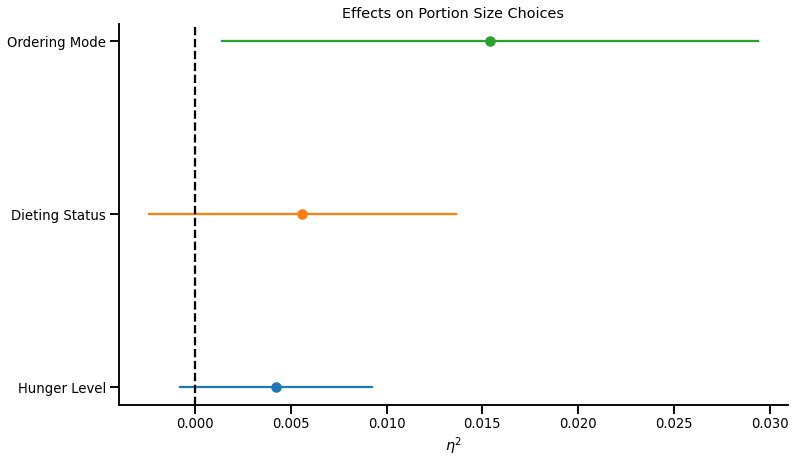

In [13]:
coeffs = [0.13, 0.15, 0.25]
coeffs_es = [
    pg.convert_effsize(c, input_type="cohen", output_type="eta-square") for c in coeffs
]
effsize_width = [0.005, 0.008, 0.014]
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
for i, (c, ew) in enumerate(zip(coeffs_es, effsize_width)):
    ax.plot([c - ew, c + ew], [i, i])
    ax.scatter([c], [i])
ax.axvline(0, ls="--", color="black")
sns.despine()
ax.set_xlabel("$\eta^2$")
ax.set_ylabel("")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Hunger Level", "Dieting Status", "Ordering Mode"])
ax.set_title("Effects on Portion Size Choices")
plt.close()
display(fig, metadata=dict(filename="Fig9"));

This graph shows that:
* Hunger Level and Dieting Status are non-significant predictors of Portion Size Choices
* Ordering from a smartphone (vs. a computer) has a significant, and directionally larger, effect on Portion Size Choices than Hunger Level or Dieting Status.

These two results suggest very low statistical power. If the study cannot detect the (well-documented) impact of hunger and dieting status on portion size choices, it is probably severely underpowered to detect any subtler effect of mode of ordering on portion size choices.

This brings me to the final type of benchmark I think we should use to evaluate effect sizes...

### Using common sense

This famous quote from Daniel Kahneman's "Thinking Fast and Slow" comes to mind:

*When I describe priming studies to audiences, the reaction is often disbelief  [. . .]. The idea you should focus on, however, is that disbelief is not an option. The results are not made up, nor are they statistical flukes. **You have no choice but to accept that the major conclusions of these studies are true.***

We now know that this conclusion was erronous, and that the audience's disbelief was in fact the appropriate reaction. The results of priming studies sounded very surprising because priming effects, when they exist, are actually (very) small, and cannot produce the spectacular changes in behavior that many studies have claimed.

We can and should apply such skepticism to effect sizes that we see in papers. Here are three of the "common sense" heuristics I am using:

1. Intuition

The advantage of marketing and psychology over say, physics or chemistry, is that we often have personal experience with the research questions. As such, if a study reports an effect that explains more than 10% of the variance in a phenomenon, we should most of the time have *some* intuition for the effect after we learn about it.  With a few exceptions, we can tell if a finding resonate with our experience or if it doesn't.

2. Proportionality

The human mind is not a Rube Goldberg machine, and most manipulations (unless extremely strong) are quickly washed out by noise. The more removed a manipulation is from a dependent variable (in time, in space, in theory...), the smaller the effect should be. As such, long causal chains (e.g., X affects W which in turn causes Y which makes people do Z), paradigms based on "seemingly unrelated tasks," "follow-up studies," between-subject designs, and subtle manipulations should produce tiny effects. On the contrary, we might expect straightforward causal relationships ("A causes B"), within-subject designs, or heavy-hand manipulations to produce large effects

3. Plausibility

Some effect sizes are simply too large. I would be extremely distrustful of someone who told me that their dad is 20ft tall, no matter how many pictures they provide, because it contradicts everything that we know about human size. Earlier in the article, I quoted the following result:

$$F(1, 58) = 81.36, p < .001, \eta^2 = .558.$$

It is an example of a result that I consider simply impossible. A contextual manipulation (whatever that is) cannot explain more than 50% of the variance in a phenomenon as multiply determined as WTP. If an effect this large existed, Plato or Aristotle would have written about it, and companies all around the world would rely on it everyday: It wouldn't be a "novel finding" in a marketing journal. Even manipulation checks typically have smaller effect sizes.


A mismatch between the expected and actual effect size might be the sign of a mistake, of an experimental confound, of something more nefarious... or simply that these heuristics sometimes fail! In any case, an effect size that doesn't pass these "common sense" should lead readers and reviewers to ask more questions.

## Some Helpful References

* [An online effect size calculator and converter](https://www.psychometrica.de/effect_size.html)
* [A visual interpretation of the Cohen's d, and some of its "intuitive" interpretations](https://rpsychologist.com/cohend/)
* [Richard, Bond, and Stokes-Zoota's "One Hundred Years of Social Psychology Quantitatively Described"](https://doi.org/10.1037/1089-2680.7.4.331)
* [Eisend's "Meta-Meta-Analysis" of marketing effect sizes (the marketing equivalent of Richard et al. 2003)](https://doi.org/10.1509/jm.14.0288)
* [Brian Nosek's Twitter thread on effect sizes](https://twitter.com/BrianNosek/status/1416427265118908419)
* [Joe Simmons' effect size estimates of tautological effects (e.g., "People who like eggs eat egg salad more often")](http://datacolada.org/18)
* [Joe Simmons' talk at SPSP 2020: "How can you tell the difference between a true finding and a false finding?"](https://youtu.be/ny-NAgYiYIs)
* [Joe Hilgard's 'Maximum Positive Control': An experimental approach to estimate the largest effect a procedure can generate](https://doi.org/10.1016/j.jesp.2020.104082)
* [Uri Simonsohn's discussion of why the concept of "average effect size" doesn't really make sense (related to the earlier discussion of the effect size of needle pricking on pain)](http://datacolada.org/33) 